# 03 — Exploration de la couche Gold : Stress Index Géopolitique × WTI

Lecture du fichier `combined/stress_index/` depuis S3 (LocalStack) pour explorer la table produite par `compute_stress_index.py`.

**Colonnes attendues :**
- **WTI** : Datetime, Open, High, Low, Close, Volume, Volatility_Range, Variation_Pct
- **GDELT lissé** : geo_I_smoothed, geo_B_smoothed, geo_S_smoothed, geo_score_raw_smoothed
- **GDELT brut** : geo_I_sum, geo_B_sum, geo_S_sum, geo_score_raw_sum
- **Métadonnées** : total_event_count, gap_duration_15m, period_main_actor
- **Percentile** : score_pct_7d

In [25]:
import io
import os
import boto3
import pandas as pd
import numpy as np

# ── Connexion S3 LocalStack ──
os.environ["AWS_ACCESS_KEY_ID"] = "test"
os.environ["AWS_SECRET_ACCESS_KEY"] = "test"
os.environ["AWS_DEFAULT_REGION"] = "eu-west-1"

s3 = boto3.client("s3", endpoint_url="http://localhost:4566")

# ── Chargement du parquet Gold (dossier Spark) ──
prefix_gold = "combined/stress_index/"
objs_gold = s3.list_objects_v2(Bucket="datalake", Prefix=prefix_gold)
parquet_keys = [o["Key"] for o in objs_gold.get("Contents", []) if o["Key"].endswith(".parquet")]

dfs = []
for key in parquet_keys:
    response = s3.get_object(Bucket="datalake", Key=key)
    dfs.append(pd.read_parquet(io.BytesIO(response["Body"].read()), engine="pyarrow"))

df_gold = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
df_gold = df_gold.sort_values("Datetime").reset_index(drop=True)

print(f"Shape : {df_gold.shape[0]} lignes × {df_gold.shape[1]} colonnes")
print(f"\nColonnes : {list(df_gold.columns)}")
print(f"\nTypes :\n{df_gold.dtypes}")
print(f"\nPlage temporelle : {df_gold['Datetime'].min()} → {df_gold['Datetime'].max()}")
df_gold.tail()

Shape : 3440 lignes × 20 colonnes

Colonnes : ['Datetime', 'Open', 'High', 'Low', 'Close', 'Volume', 'Volatility_Range', 'Variation_Pct', 'geo_I_smoothed', 'geo_B_smoothed', 'geo_S_smoothed', 'geo_score_raw_smoothed', 'geo_I_sum', 'geo_B_sum', 'geo_S_sum', 'geo_score_raw_sum', 'total_event_count', 'gap_duration_15m', 'period_main_actor', 'score_pct_7d']

Types :
Datetime                  datetime64[ns]
Open                             float64
High                             float64
Low                              float64
Close                            float64
Volume                             int64
Volatility_Range                 float64
Variation_Pct                    float64
geo_I_smoothed                   float64
geo_B_smoothed                   float64
geo_S_smoothed                   float64
geo_score_raw_smoothed           float64
geo_I_sum                        float64
geo_B_sum                        float64
geo_S_sum                        float64
geo_score_raw_sum   

,Datetime,Open,High,Low,Close,Volume,Volatility_Range,Variation_Pct,geo_I_smoothed,geo_B_smoothed,geo_S_smoothed,geo_score_raw_smoothed,geo_I_sum,geo_B_sum,geo_S_sum,geo_score_raw_sum,total_event_count,gap_duration_15m,period_main_actor,score_pct_7d
3435,2026-03-02 19:30:00,71.230003,71.330002,71.110001,71.139999,7335,0.22,-0.1264,340.0,275.797010,249.689955,4913.090615,340.0,275.797010,249.689955,4913.090615,136.0,1,IRN,11.96
3436,2026-03-02 19:45:00,71.139999,71.169998,70.830002,70.900002,9478,0.34,-0.3374,607.0,428.998319,418.173660,10575.352334,607.0,428.998319,418.173660,10575.352334,214.0,1,IRN,28.02
3437,2026-03-02 20:00:00,70.900002,72.489998,70.900002,72.300003,23405,1.59,1.9746,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1,NONE,0.00
3438,2026-03-02 20:15:00,72.309998,72.779999,71.480003,72.620003,19943,1.30,0.4426,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1,NONE,0.00
3439,2026-03-02 20:30:00,72.629997,72.699997,72.260002,72.489998,5600,0.44,-0.1790,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1,NONE,0.00


In [14]:
print(df_gold['period_main_actor'].unique())

['SAU' 'IRN' 'RUS' 'CAN' 'USA' 'IRQ' 'VEN' 'FRA' 'BRA' 'NGA' 'NONE']


In [15]:
# ═══════════════════════════════════════════════
# Statistiques descriptives
# ═══════════════════════════════════════════════
print("Valeurs manquantes :")
print(df_gold.isnull().sum())
print(f"\nDoublons sur Datetime : {df_gold.duplicated(subset=['Datetime']).sum()}")
print(f"\nStatistiques numériques :")
df_gold.describe().round(4)

df_gold.tail()

Valeurs manquantes :
Datetime                  0
Open                      0
High                      0
Low                       0
Close                     0
Volume                    0
Volatility_Range          0
Variation_Pct             1
geo_I_smoothed            0
geo_B_smoothed            0
geo_S_smoothed            0
geo_score_raw_smoothed    0
geo_I_sum                 0
geo_B_sum                 0
geo_S_sum                 0
geo_score_raw_sum         0
total_event_count         0
gap_duration_15m          0
period_main_actor         0
score_pct_7d              0
dtype: int64

Doublons sur Datetime : 0

Statistiques numériques :


,Datetime,Open,High,Low,Close,Volume,Volatility_Range,Variation_Pct,geo_I_smoothed,geo_B_smoothed,geo_S_smoothed,geo_score_raw_smoothed,geo_I_sum,geo_B_sum,geo_S_sum,geo_score_raw_sum,total_event_count,gap_duration_15m,period_main_actor,score_pct_7d
3435,2026-03-02 19:30:00,71.230003,71.330002,71.110001,71.139999,7335,0.22,-0.1264,340.0,275.797010,249.689955,4913.090615,340.0,275.797010,249.689955,4913.090615,136.0,1,IRN,11.96
3436,2026-03-02 19:45:00,71.139999,71.169998,70.830002,70.900002,9478,0.34,-0.3374,607.0,428.998319,418.173660,10575.352334,607.0,428.998319,418.173660,10575.352334,214.0,1,IRN,28.02
3437,2026-03-02 20:00:00,70.900002,72.489998,70.900002,72.300003,23405,1.59,1.9746,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1,NONE,0.00
3438,2026-03-02 20:15:00,72.309998,72.779999,71.480003,72.620003,19943,1.30,0.4426,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1,NONE,0.00
3439,2026-03-02 20:30:00,72.629997,72.699997,72.260002,72.489998,5600,0.44,-0.1790,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,1,NONE,0.00


In [24]:
df_gold.describe().round(4)

,Datetime,Open,High,Low,Close,Volume,Volatility_Range,Variation_Pct,geo_I_smoothed,geo_B_smoothed,geo_S_smoothed,geo_score_raw_smoothed,geo_I_sum,geo_B_sum,geo_S_sum,geo_score_raw_sum,total_event_count,gap_duration_15m,score_pct_7d
count,3440,3440.0000,3440.0000,3440.0000,3440.0000,3440.0000,3440.0000,3439.0000,3440.0000,3440.0000,3440.0000,3440.0000,3440.0000,3440.0000,3440.0000,3.440000e+03,3440.0000,3440.0000,3440.0000
mean,2026-02-01 16:59:21.279069696,62.4888,62.5882,62.3861,62.4933,3737.0177,0.2021,0.0074,314.1967,305.1522,281.0067,3657.4382,450.6520,431.6112,400.0407,5.431823e+03,213.4544,1.6160,29.4238
min,2026-01-04 23:00:00,55.8700,55.9700,55.7600,55.8700,0.0000,0.0200,-5.8276,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000000e+00,0.0000,1.0000,0.0000
25%,2026-01-16 10:11:15,59.8300,59.9075,59.7600,59.8400,692.5000,0.1100,-0.0956,241.5000,245.5217,226.0834,2571.9142,241.5000,245.5217,226.0834,2.571914e+03,122.0000,1.0000,19.1075
50%,2026-02-03 04:07:30,62.8100,62.8900,62.7200,62.8100,2016.0000,0.1600,0.0000,303.0000,297.1845,273.3297,3351.8872,303.0000,297.1845,273.3297,3.351887e+03,147.0000,1.0000,27.1050
75%,2026-02-17 12:33:45,64.8900,64.9900,64.7800,64.8925,5005.2500,0.2425,0.1154,365.5000,352.1552,324.7319,4342.2105,365.5000,352.2548,324.7319,4.342211e+03,175.0000,1.0000,37.0725
max,2026-03-02 20:30:00,73.2300,73.3700,72.8200,73.2400,118942.0000,2.5900,7.7872,1332.4102,866.8250,829.3318,35947.1250,74476.0000,65396.4938,60381.2672,1.510912e+06,32369.0000,302.0000,100.0000
std,NaN,3.2474,3.2692,3.2210,3.2483,5224.7055,0.1615,0.2926,105.7803,88.8918,83.0236,1761.8512,2405.1654,2173.0015,2050.6909,3.522072e+04,1073.5637,10.7413,15.0446


---
## Visualisations

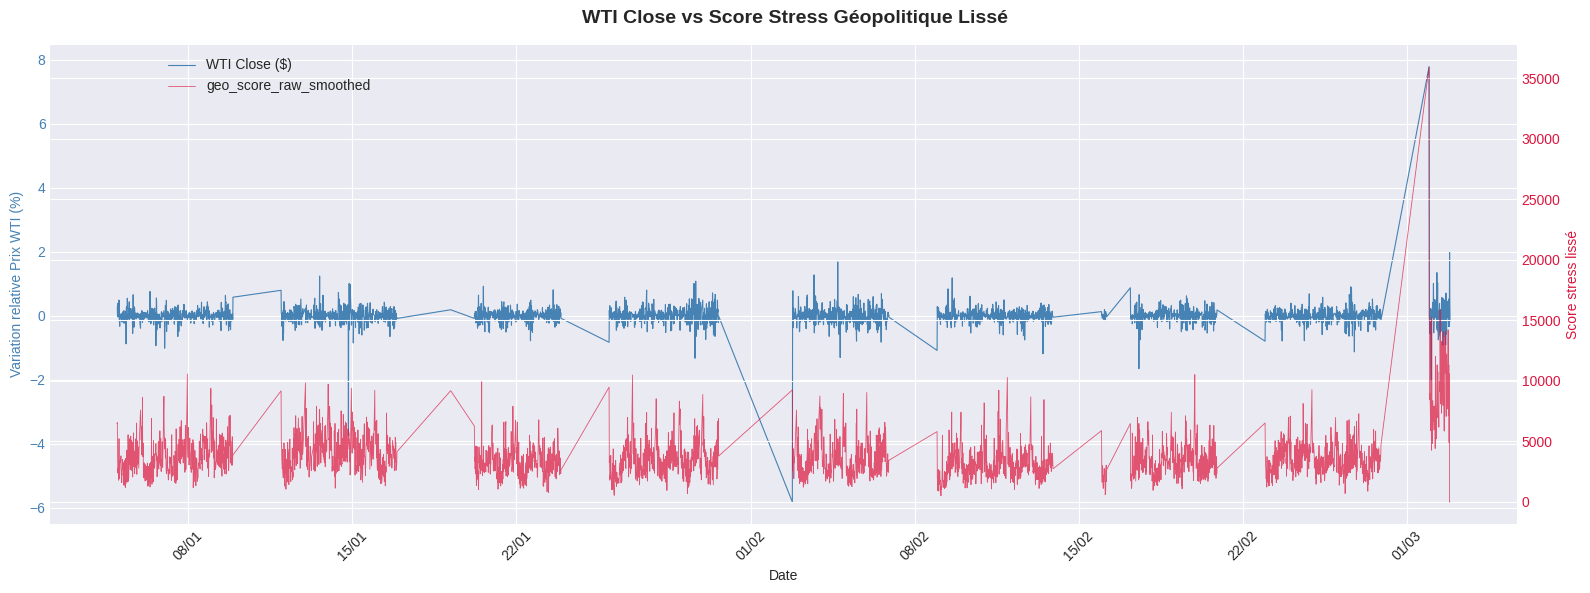

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-v0_8-darkgrid")

# ═══════════════════════════════════════════════
# 1. Prix WTI (Close) + Score Stress lissé (double axe)
# ═══════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.plot(df_gold["Datetime"], df_gold["Variation_Pct"], color="steelblue", linewidth=0.8, label="WTI Close ($)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Variation relative Prix WTI (%)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(df_gold["Datetime"], df_gold["geo_score_raw_smoothed"], color="crimson", linewidth=0.6, alpha=0.7, label="geo_score_raw_smoothed")
ax2.set_ylabel("Score stress lissé", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")

fig.suptitle("WTI Close vs Score Stress Géopolitique Lissé", fontweight="bold", fontsize=14)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.92))
plt.tight_layout()
plt.show()

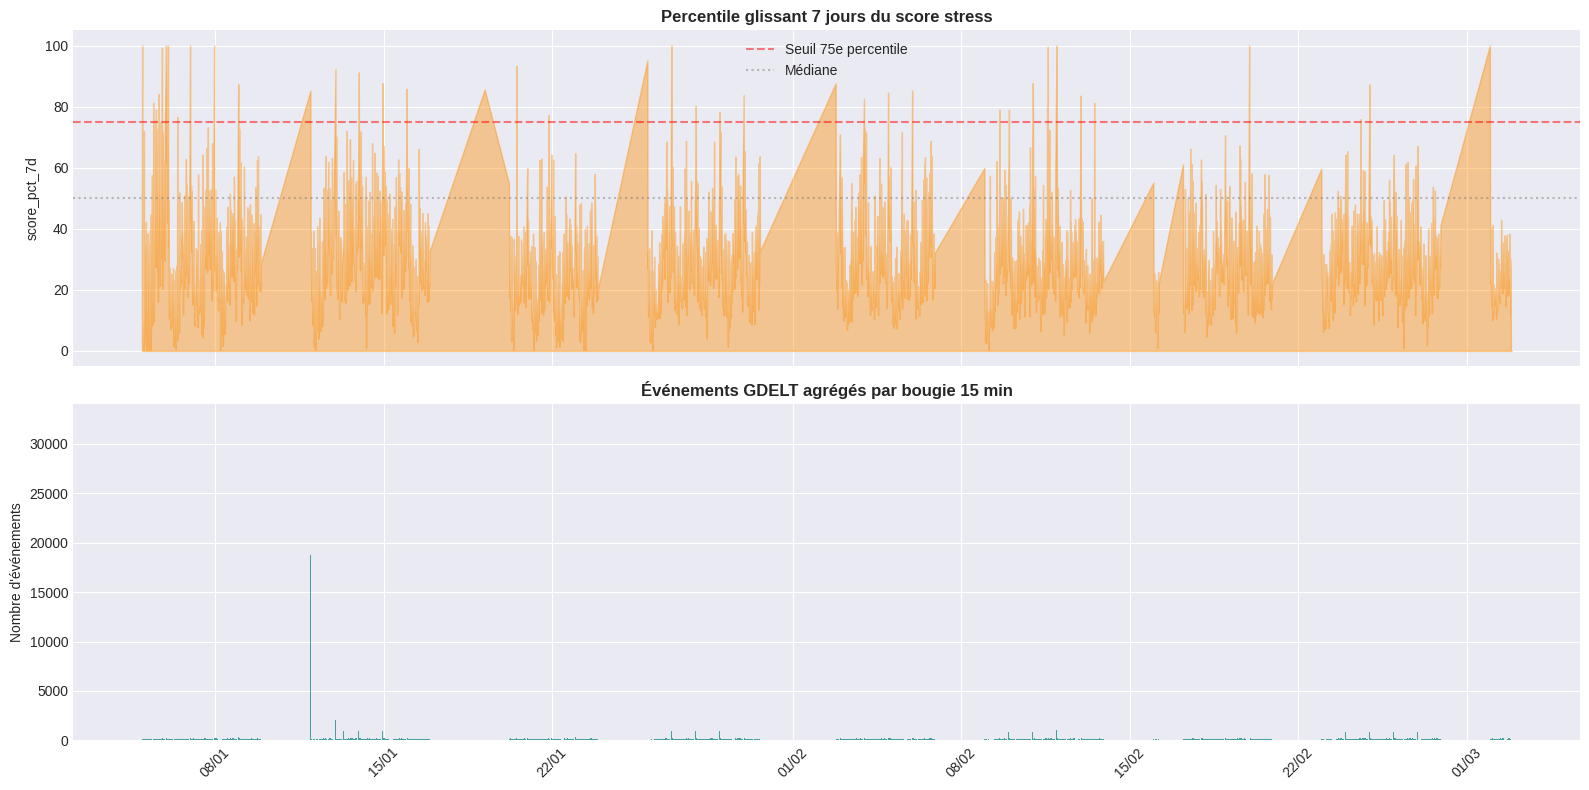

In [17]:
# ═══════════════════════════════════════════════
# 2. Percentile 7 jours (score_pct_7d) + Nombre d'événements
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Percentile 7j
axes[0].fill_between(df_gold["Datetime"], df_gold["score_pct_7d"], alpha=0.4, color="darkorange")
axes[0].axhline(y=75, color="red", linestyle="--", alpha=0.5, label="Seuil 75e percentile")
axes[0].axhline(y=50, color="gray", linestyle=":", alpha=0.5, label="Médiane")
axes[0].set_ylabel("score_pct_7d")
axes[0].set_title("Percentile glissant 7 jours du score stress", fontweight="bold")
axes[0].legend()

# Nombre d'événements
axes[1].bar(df_gold["Datetime"], df_gold["total_event_count"], color="teal", alpha=0.7, width=0.01)
axes[1].set_ylabel("Nombre d'événements")
axes[1].set_title("Événements GDELT agrégés par bougie 15 min", fontweight="bold")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

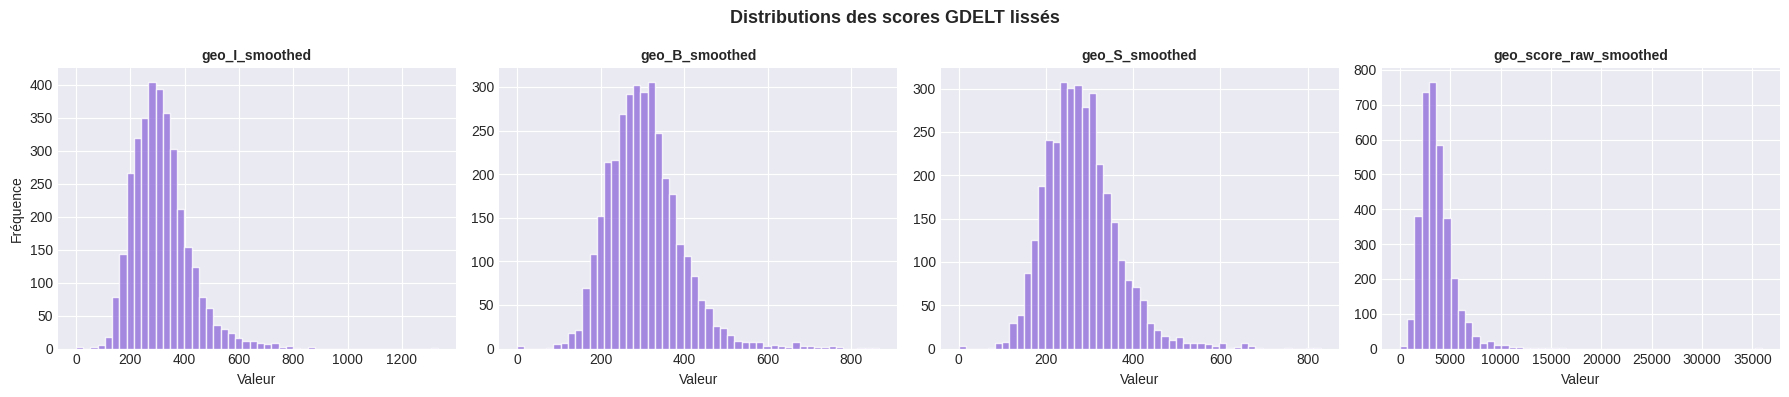

In [18]:
# ═══════════════════════════════════════════════
# 3. Distributions des scores lissés
# ═══════════════════════════════════════════════
score_cols_smoothed = ["geo_I_smoothed", "geo_B_smoothed", "geo_S_smoothed", "geo_score_raw_smoothed"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(score_cols_smoothed):
    axes[i].hist(df_gold[col].dropna(), bins=50, color="mediumpurple", alpha=0.8, edgecolor="white")
    axes[i].set_title(col, fontweight="bold", fontsize=10)
    axes[i].set_xlabel("Valeur")
    axes[i].set_ylabel("Fréquence" if i == 0 else "")

plt.suptitle("Distributions des scores GDELT lissés", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

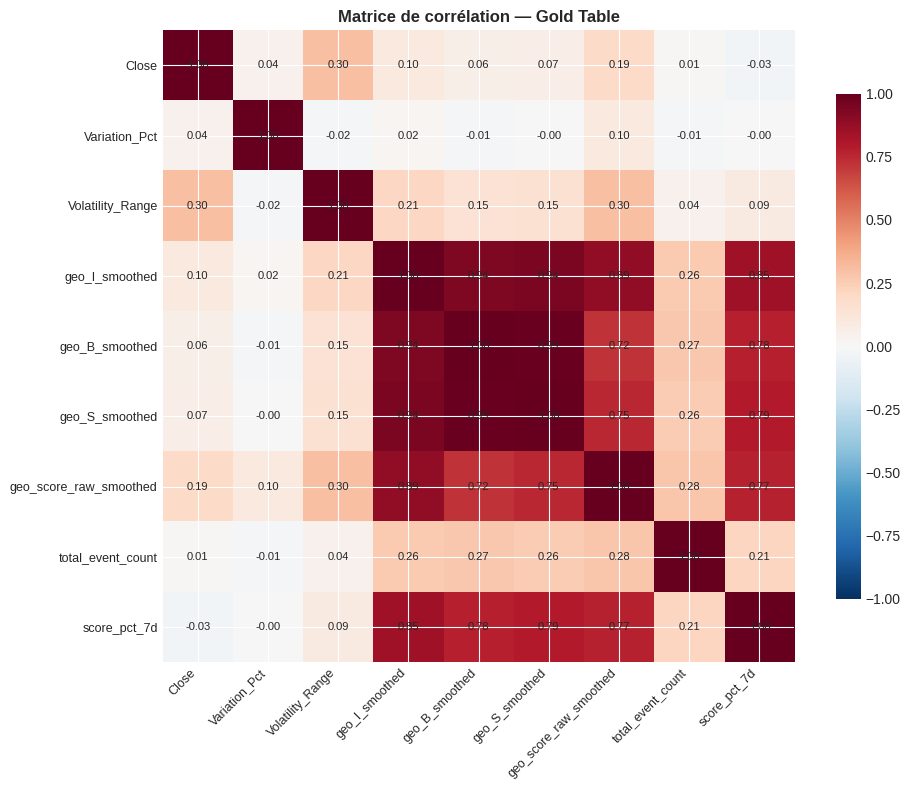

In [19]:
# ═══════════════════════════════════════════════
# 4. Matrice de corrélation
# ═══════════════════════════════════════════════
corr_cols = [
    "Close", "Variation_Pct", "Volatility_Range",
    "geo_I_smoothed", "geo_B_smoothed", "geo_S_smoothed", "geo_score_raw_smoothed",
    "total_event_count", "score_pct_7d",
]
corr_matrix = df_gold[corr_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

# Annotations
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.title("Matrice de corrélation — Gold Table", fontweight="bold")
plt.tight_layout()
plt.show()

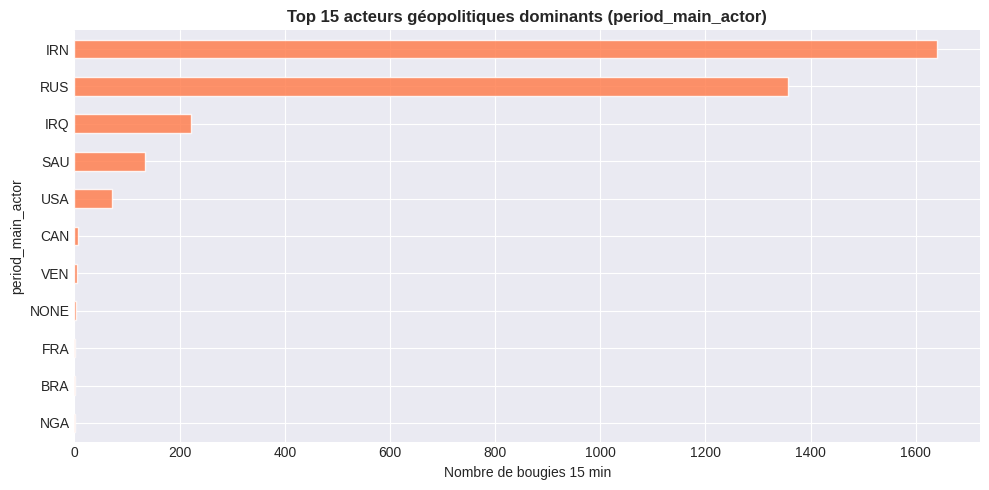

In [20]:
# ═══════════════════════════════════════════════
# 5. Top acteurs géopolitiques (period_main_actor)
# ═══════════════════════════════════════════════
top_actors = df_gold["period_main_actor"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_actors.plot(kind="barh", color="coral", alpha=0.85, edgecolor="white", ax=ax)
ax.set_title("Top 15 acteurs géopolitiques dominants (period_main_actor)", fontweight="bold")
ax.set_xlabel("Nombre de bougies 15 min")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

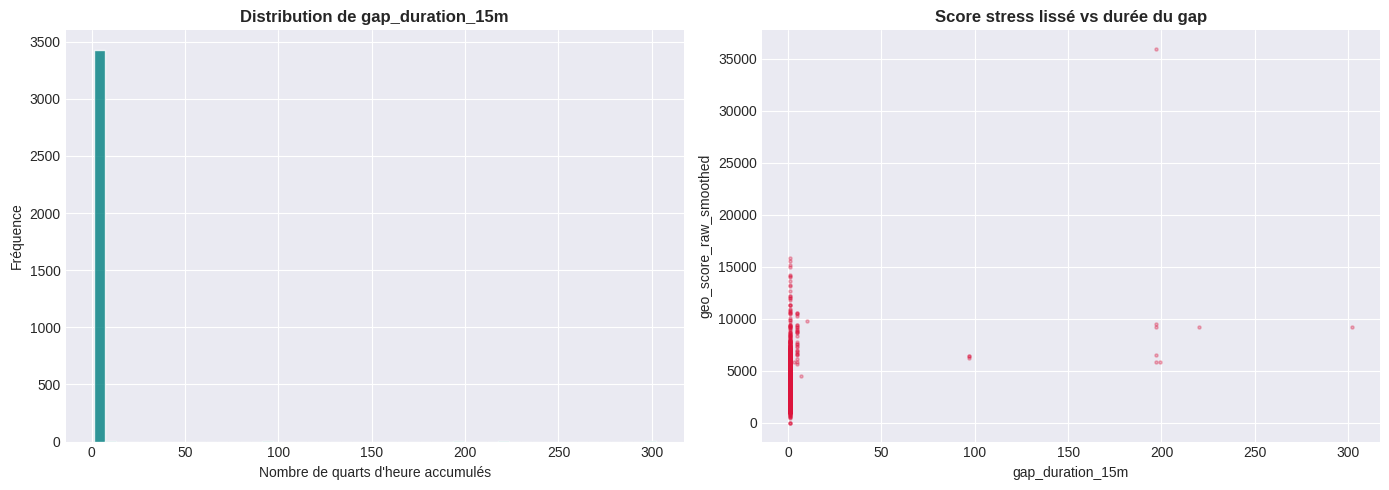

In [21]:
# ═══════════════════════════════════════════════
# 6. Gap duration : analyse du forward mapping
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution de gap_duration_15m
axes[0].hist(df_gold["gap_duration_15m"].dropna(), bins=50, color="teal", alpha=0.8, edgecolor="white")
axes[0].set_title("Distribution de gap_duration_15m", fontweight="bold")
axes[0].set_xlabel("Nombre de quarts d'heure accumulés")
axes[0].set_ylabel("Fréquence")

# Score stress vs gap_duration (les réouvertures après longs gaps sont-elles plus stressées ?)
axes[1].scatter(df_gold["gap_duration_15m"], df_gold["geo_score_raw_smoothed"],
               alpha=0.3, s=5, color="crimson")
axes[1].set_title("Score stress lissé vs durée du gap", fontweight="bold")
axes[1].set_xlabel("gap_duration_15m")
axes[1].set_ylabel("geo_score_raw_smoothed")

plt.tight_layout()
plt.show()

In [22]:
# ═══════════════════════════════════════════════
# 7. Aperçu des lignes avec le score stress le plus élevé
# ═══════════════════════════════════════════════
top_stress = df_gold.nlargest(20, "geo_score_raw_smoothed")[
    ["Datetime", "Close", "Variation_Pct", "geo_score_raw_smoothed",
     "score_pct_7d", "total_event_count", "period_main_actor", "gap_duration_15m"]
]
print("Top 20 bougies avec le score stress lissé le plus élevé :")
top_stress

Top 20 bougies avec le score stress lissé le plus élevé :


,Datetime,Close,Variation_Pct,geo_score_raw_smoothed,score_pct_7d,total_event_count,period_main_actor,gap_duration_15m
3353,2026-03-01 23:00:00,72.529999,7.7872,35947.124960,100.00,25438.0,IRN,197
3398,2026-03-02 10:15:00,72.029999,0.0000,15853.789940,43.00,270.0,IRN,1
3354,2026-03-01 23:15:00,72.529999,0.0000,15521.135229,42.05,205.0,IRN,1
3364,2026-03-02 01:45:00,69.730003,0.0861,15225.079265,41.21,232.0,IRN,1
3361,2026-03-02 01:00:00,70.959999,-1.1562,14946.502593,40.42,202.0,IRN,1
3431,2026-03-02 18:30:00,70.940002,0.0705,14223.949431,38.37,252.0,IRN,1
3421,2026-03-02 16:00:00,70.599998,-0.9123,14117.765099,38.07,205.0,IRN,1
3411,2026-03-02 13:30:00,72.330002,0.0138,14025.552423,37.81,232.0,IRN,1
3417,2026-03-02 15:00:00,71.400002,0.4926,13627.489604,36.68,203.0,IRN,1
3403,2026-03-02 11:30:00,71.779999,-0.0279,13260.737830,35.64,206.0,IRQ,1


In [26]:
# Diagnostic GDELT
print("=== Scores GDELT lissés ===")
for col in ["geo_I_smoothed", "geo_B_smoothed", "geo_S_smoothed", "geo_score_raw_smoothed"]:
    print(f"{col}: min={df_gold[col].min():.4f}, max={df_gold[col].max():.4f}, mean={df_gold[col].mean():.4f}, non-zero={(df_gold[col] != 0).sum()}/{len(df_gold)}")

print(f"\n=== period_main_actor ===")
print(df_gold["period_main_actor"].value_counts())

print(f"\n=== total_event_count ===")
print(f"min={df_gold['total_event_count'].min()}, max={df_gold['total_event_count'].max()}, mean={df_gold['total_event_count'].mean():.2f}")
print(f"Bougies avec 0 événements : {(df_gold['total_event_count'] == 0).sum()}/{len(df_gold)}")

print(f"\n=== score_pct_7d ===")
print(df_gold["score_pct_7d"].describe())

=== Scores GDELT lissés ===
geo_I_smoothed: min=0.0000, max=1332.4102, mean=314.1967, non-zero=3437/3440
geo_B_smoothed: min=0.0000, max=866.8250, mean=305.1522, non-zero=3437/3440
geo_S_smoothed: min=0.0000, max=829.3318, mean=281.0067, non-zero=3437/3440
geo_score_raw_smoothed: min=0.0000, max=35947.1250, mean=3657.4382, non-zero=3437/3440

=== period_main_actor ===
period_main_actor
IRN     1640
RUS     1356
IRQ      221
SAU      135
USA       72
CAN        6
VEN        4
NONE       3
FRA        1
BRA        1
NGA        1
Name: count, dtype: int64

=== total_event_count ===
min=0.0, max=32369.0, mean=213.45
Bougies avec 0 événements : 3/3440

=== score_pct_7d ===
count    3440.000000
mean       29.423791
std        15.044578
min         0.000000
25%        19.107500
50%        27.105000
75%        37.072500
max       100.000000
Name: score_pct_7d, dtype: float64
